# Comprensión y Análisis Exploratorio de Datos (EDA)
### Proyecto Integrador M5 — Scoring Crediticio

Este notebook realiza el análisis exploratorio del dataset `Base_de_datos.csv`, correspondiente al histórico de créditos de la fintech. El objetivo es comprender la estructura, calidad y relaciones de los datos antes de avanzar a la etapa de ingeniería de características y modelado.

**Variable objetivo:** `Pago_atiempo` (1 = pagó a tiempo, 0 = no pagó a tiempo).

Estructura de este notebook:
1. Exploración inicial de datos
2. Corrección de tipos y limpieza básica
3. Análisis univariable
4. Análisis bivariable (contra la variable objetivo)
5. Análisis multivariable
6. Conclusiones y próximos pasos


## 1. Exploración inicial de datos

Cargamos el dataset y hacemos un primer reconocimiento: dimensiones, tipos de dato originales, y presencia de nulos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

pd.set_option("display.float_format", "{:,.2f}".format)

df = pd.read_csv("../../Base_de_datos.csv")
df.head()


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


In [2]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()


Filas: 10763, Columnas: 23
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta               

In [3]:
# Conteo de nulos por columna, ordenado de mayor a menor
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "% del total": porcentaje_nulos})


,nulos,% del total
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06
salario_cliente,0,0.00
tipo_laboral,0,0.00
edad_cliente,0,0.00


Se detectaron las columnas tendencia_ingresos y promedio_ingresos_datacredito en las que los nulos eran mas del 10%

In [4]:
# Revisión de valores únicos en columnas 'object', para detectar
# representaciones inconsistentes de nulos (strings vacíos, 'NaN' como texto, etc.)
for c in df.select_dtypes(include="object").columns:
    print(f"--- {c} ---")
    print(df[c].unique()[:15])
    print()


--- fecha_prestamo ---
<ArrowStringArray>
['2024-12-21 11:31:35', '2025-04-22 09:47:35', '2026-01-08 12:22:40',
 '2025-08-04 12:04:10', '2025-04-26 11:24:26', '2025-06-10 08:54:01',
 '2025-08-09 13:00:44', '2025-08-18 12:49:19', '2025-05-30 09:11:18',
 '2024-12-31 14:32:59', '2025-03-21 12:29:32', '2025-03-25 17:19:59',
 '2025-03-15 12:03:39', '2024-12-17 10:40:13', '2025-01-01 16:57:31']
Length: 15, dtype: str

--- tipo_laboral ---
<ArrowStringArray>
['Independiente', 'Empleado']
Length: 2, dtype: str

--- tendencia_ingresos ---
<ArrowStringArray>
[    'Estable',   'Creciente',           nan, 'Decreciente',        '8315',
           '0',      '158042',        '3978',        '9147',      '168750',
      '-28589',     '1000000',     '-566272',       '24702',       '31837']
Length: 15, dtype: str



C:\Users\asirc\AppData\Local\Temp\ipykernel_2420\2194512180.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


### Se detectaron valores que no corresponden a las categorias de la columna tendencia_ingresos

In [5]:
print(df['tendencia_ingresos'].unique())

<ArrowStringArray>
[    'Estable',   'Creciente',           nan, 'Decreciente',        '8315',
           '0',      '158042',        '3978',        '9147',      '168750',
      '-28589',     '1000000',     '-566272',       '24702',       '31837',
      '122727',      '417087',        '9090',      '173031',      '-70715',
     '-435177',     '-702927',       '-4105',       '54683',       '22832',
      '209090',        '5697',       '10808',        '-288',     '-164315',
     '2029000',       '17181',       '15245',       '82657',       '52862',
     '1817052',       '75761',      '146918',     '1123000',       '15090',
     '4250635',       '22363',     '-101368',       '86286',       '65988',
       '77975',     '-224714']
Length: 47, dtype: str


### Aplicando un filtro se logran discriminar 43 tipos distintos de categorias cuando deberia haber solo 3 (Estable, Creciente y Decreciente)

In [6]:
categorias_validas = ["Estable", "Creciente", "Decreciente"]
df.loc[~df["tendencia_ingresos"].isin(categorias_validas), "tendencia_ingresos"] = np.nan

Se convierten los datos erroneos en NaN

In [7]:
df["tendencia_ingresos"].isnull().sum()

np.int64(2990)

Corrección de tendencia_ingresos: al revisar los valores únicos de esta columna, se detectaron 43 valores numéricos (8315, -28589, 1000000) mezclados junto a las 3 categorías esperadas (Estable, Creciente, Decreciente). Estos números no representan ninguna categoría válida. 
Todo indica un error de carga de datos, probablemente un desplazamiento de columnas al generar el archivo original, ya que no siguen ningún patrón de codificación reconocible (43 valores distintos y sin repetición, en un rango disperso de -700.000 a +4.250.000).

Se reemplazaron esos valores por NaN, ya que no es posible recuperar la categoría real que debieron tener. Esto afectó a 58 filas en total (más que los 43 valores únicos, porque algunos de esos números corruptos se repiten en más de un registro). Como resultado, los nulos reales de esta columna subieron de 2.932 a 2.990 (27,8% del total de filas)

## 2. Corrección de tipos de dato y limpieza

Con lo detectado en el paso anterior, unificamos la representación de nulos y convertimos cada columna a su tipo correcto (numérico, categórico, fecha, booleano).

In [8]:
# Unificar representaciones de nulos: reemplazamos strings vacíos y marcadores
# comunes de "sin dato" por np.nan, para que pandas los trate de forma consistente.
marcadores_nulos = ["", " ", "NaN", "nan", "N/A", "n/a", "-", "None"]
df = df.replace(marcadores_nulos, np.nan)


In [9]:
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")
df["fecha_prestamo"].describe()


count                         10763
mean     2025-04-16 23:06:02.111121
min             2024-11-26 09:17:04
25%      2025-01-20 17:33:07.500000
50%             2025-03-27 16:23:12
75%             2025-06-16 13:27:58
max             2026-04-26 18:43:52
Name: fecha_prestamo, dtype: object

In [10]:
# Variable objetivo y columnas categóricas explícitas como 'category'
columnas_categoricas = ["tipo_laboral", "tendencia_ingresos"]
for c in columnas_categoricas:
    if c in df.columns:
        df[c] = df[c].astype("category")


df.dtypes


tipo_credito                              int64
fecha_prestamo                   datetime64[us]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

In [11]:
# Re-chequeo de nulos después de las conversiones de tipo
nulos_post = df.isnull().sum().sort_values(ascending=False)
nulos_post[nulos_post > 0]


tendencia_ingresos               2990
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
dtype: int64

**Decisión sobre nulos:**
- `tendencia_ingresos` (27.8%) y `promedio_ingresos_datacredito` (27.2%): porcentaje demasiado alto para imputar sin distorsionar la distribución real. Se opta por crear una categoría/flag explícito de "dato faltante" en vez de rellenar con un valor inventado, para no introducir sesgo.
- `saldo_mora_codeudor` (5.5%): se interpreta que el nulo indica ausencia de codeudor (no un dato perdido), por lo que la imputación correcta es 0, no la mediana.
- `saldo_principal`, `saldo_mora`, `saldo_total` (<4%): volumen bajo, se imputará con la mediana por ser más robusta a outliers que la media.
- `puntaje_datacredito` (0.06%, 6 filas): volumen insignificante, se eliminarán esas filas directamente.

Esta estrategia de imputación, ya definida, se implementa en `ft_engineering.py` como parte del pipeline de procesamiento de datos.

## 3. Análisis univariable

Separamos las variables en numéricas y categóricas, y describimos la distribución de cada una por separado.

In [12]:
numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "Pago_atiempo" in numericas:
    numericas.remove("Pago_atiempo")  # se aparta debiado a que es la variable objetivo

categoricas = df.select_dtypes(include=["category", "object"]).columns.tolist()

print("Numéricas:", numericas)
print("Categóricas:", categoricas)


Numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']
Categóricas: ['tipo_laboral', 'tendencia_ingresos']


In [13]:
df[numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
tipo_credito,"10,763.00",5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80"
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00


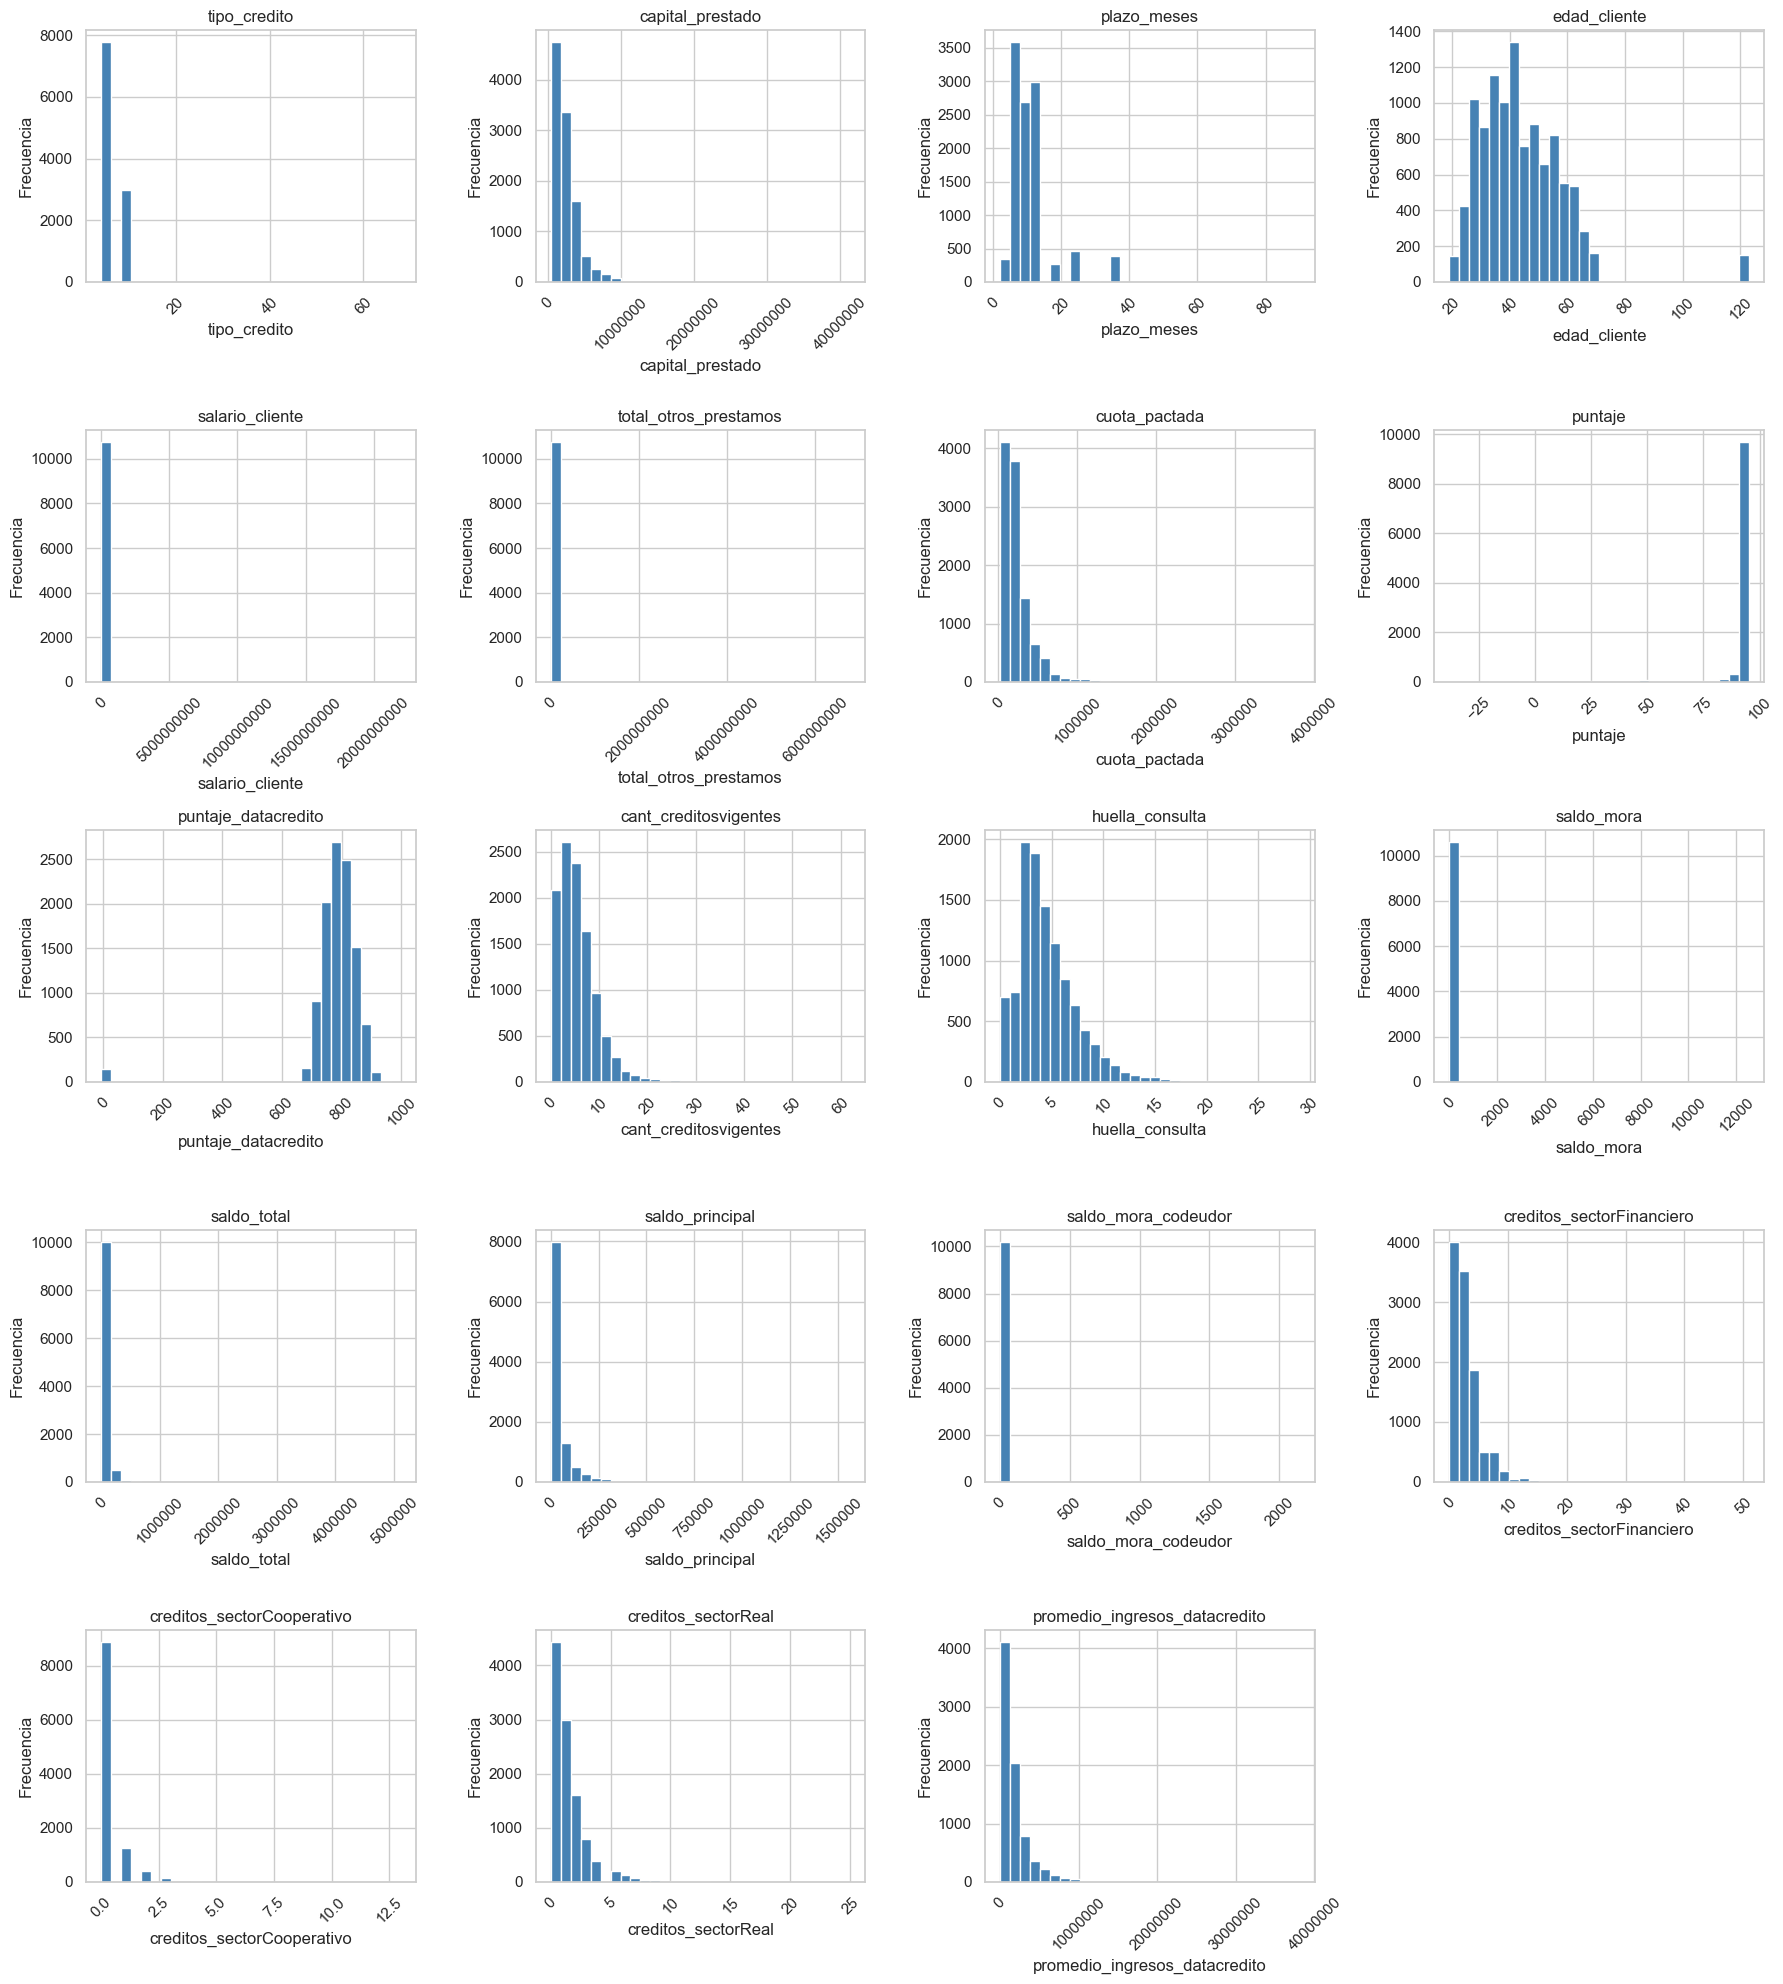

In [14]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(nrows=(len(numericas) + 3) // 4, ncols=4, figsize=(18, 4 * ((len(numericas) + 3) // 4)))
axes = axes.flatten()
for i, col in enumerate(numericas):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].ticklabel_format(style="plain", axis="x") 
    axes[i].tick_params(axis="x", rotation=45)  
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Se observa que en 'edad_cliente' hay una anomalia fuera de parametros de edad

In [15]:
df["edad_cliente"].describe()

count   10,763.00
mean        43.95
std         15.06
min         19.00
25%         33.00
50%         42.00
75%         53.00
max        123.00
Name: edad_cliente, dtype: float64

se detectan clientes de maximo 123 años de edad

In [16]:
(df["edad_cliente"] > 90).sum()

np.int64(150)

In [17]:
df["edad_cliente"].sort_values(ascending=False).head(20)

7113    123
7032    123
7152    122
7153    122
7151    122
7156    122
7155    122
7157    122
7119    122
7118    122
7117    122
7134    122
7150    122
7075    122
7076    122
7077    122
7078    122
7079    122
7107    122
7106    122
Name: edad_cliente, dtype: int64

In [18]:
df["edad_cliente"].value_counts().sort_index().tail(15)

edad_cliente
58     185
59     187
60     179
61     150
62     136
63     135
64     117
65     101
66      90
67      94
68     109
69      55
121      4
122    144
123      2
Name: count, dtype: int64

Las edades varian de los 69 años a directamente los 121 años hasta los 123, siendo los 122 años los que mas concentracion de clientes tiene con 144 clientes cargados con ese valor

In [19]:
df.loc[df["edad_cliente"] > 90, ["salario_cliente", "puntaje", "Pago_atiempo"]].describe()

,salario_cliente,puntaje,Pago_atiempo
count,150.00,150.00,150.00
mean,"690,836,498.24",87.78,0.93
std,"1,863,481,540.37",24.04,0.26
min,"1,320,000.00",-20.63,0.00
25%,"15,972,765.00",95.23,1.00
50%,"88,289,424.00",95.23,1.00
75%,"451,022,979.25",95.23,1.00
max,"13,258,352,050.00",95.23,1.00


Se revisan `salario_cliente`, `puntaje` y `Pago_atiempo` en este subgrupo de filas con edad anómala, para determinar el alcance real de la corrupción: `salario_cliente` confirma el mismo patrón de valores absurdos (media de $690M, muy por encima del promedio general de $17M). La revisión de `Pago_atiempo` (93% de pagos a tiempo en este subgrupo, vs. distribución general del dataset) permite evaluar si eliminar estas filas introduciría un sesgo hacia una clase particular del target.

In [20]:
filas_corruptas = df[df["edad_cliente"] > 90]
filas_corruptas[["capital_prestado", "plazo_meses", "cuota_pactada", "puntaje_datacredito"]].describe()

,capital_prestado,plazo_meses,cuota_pactada,puntaje_datacredito
count,150.00,150.00,150.00,147.00
mean,"5,840,042.28",8.75,"605,866.21",10.37
std,"5,411,849.96",2.25,"530,611.17",88.64
min,"881,076.00",2.00,"75,792.00",0.00
25%,"3,056,859.90",9.00,"313,222.50",0.00
50%,"4,471,677.60",9.00,"448,179.50",0.00
75%,"7,132,161.30",10.00,"686,864.50",0.00
max,"41,444,152.80",12.00,"3,816,752.00",774.00


In [21]:
df["Pago_atiempo"].value_counts(normalize=True).round(3)

Pago_atiempo
1   0.95
0   0.05
Name: proportion, dtype: float64

**Distribución de la variable objetivo:** el dataset muestra un desbalance de clases marcado — 95% de los créditos fueron pagados a tiempo (`Pago_atiempo=1`) y solo 5% no lo fueron (`Pago_atiempo=0`). Este desbalance es significativamente más fuerte que casos típicos de referencia, lo que tiene una implicación directa para el modelado: un clasificador entrenado sin ajustes podría alcanzar ~95% de accuracy simplemente prediciendo "paga a tiempo" para todos los casos, sin detectar ningún caso real de no pago (Recall=0 para la clase minoritaria). Esto deberá abordarse mediante técnicas de balanceo de clases (por ejemplo, SMOTE) y priorizando métricas como Recall, F1 o AUC por sobre el Accuracy al evaluar modelos.

In [22]:
# Reemplazo de valores corruptos en 'edad_cliente' y 'salario_cliente' por np.nan
df.loc[df["edad_cliente"] > 90, ["edad_cliente", "salario_cliente"]] = np.nan

In [23]:
# Verificación de edad_cliente después de la limpieza
df["edad_cliente"].describe()

count   10,613.00
mean        42.85
std         11.95
min         19.00
25%         33.00
50%         42.00
75%         52.00
max         69.00
Name: edad_cliente, dtype: float64

con este cambio ya no habra mas outliers grandes como habiamos visto anteriormente, lo unico que variara sera que habra 150 nulos en su lugar.

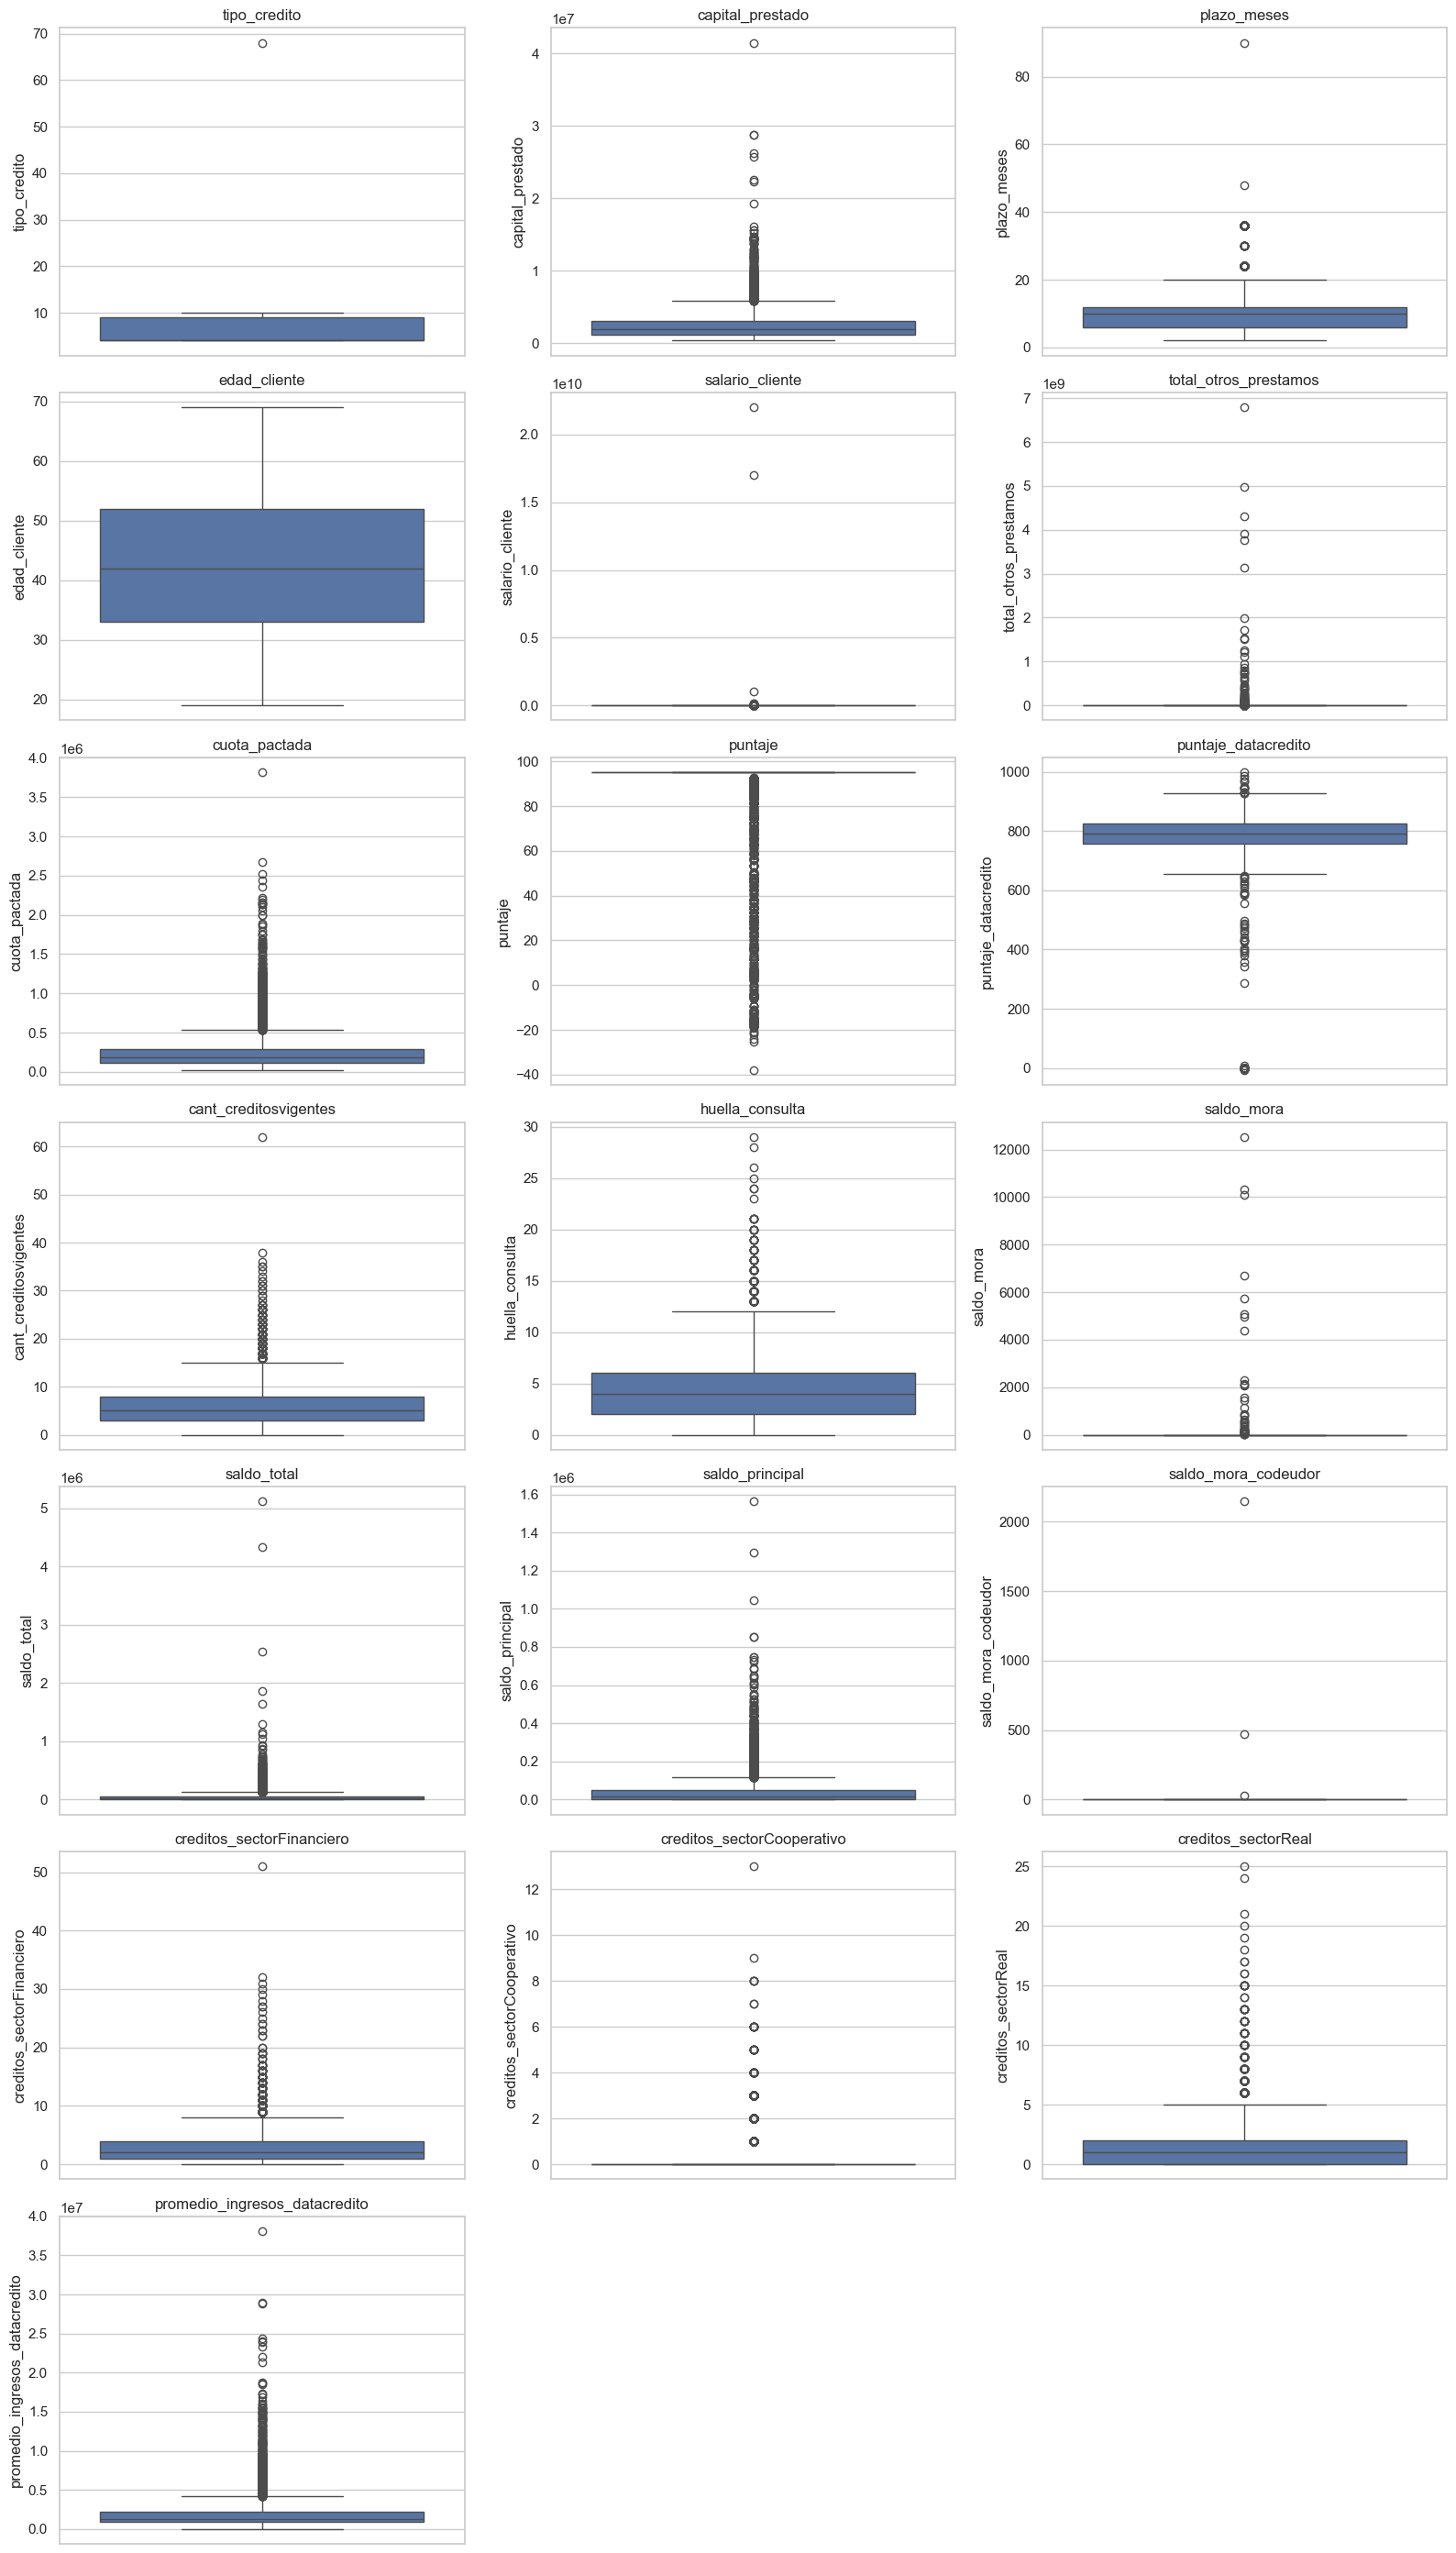

In [24]:
# Boxplots individuales, para detectar outliers de forma más clara que en el histograma
fig, axes = plt.subplots(nrows=(len(numericas) + 2) // 3, ncols=3, figsize=(16, 4 * ((len(numericas) + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numericas):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [25]:
df[df["salario_cliente"] > 100_000_000][["edad_cliente", "salario_cliente"]]

,edad_cliente,salario_cliente
2866,69.00,"16,991,100,000.00"
4995,65.00,"154,014,666.00"
5735,44.00,"22,000,000,000.00"
7436,35.00,"120,000,000.00"
9832,32.00,"1,035,000,000.00"


In [26]:
df["puntaje"].value_counts().head(10)

puntaje
95.23    9407
89.98      99
89.23      82
92.00      73
47.61      59
84.73      59
91.73      56
92.23      51
90.56      46
91.41      45
Name: count, dtype: int64

In [27]:
df.loc[[2866, 4995, 5735, 7436, 9832], ["salario_cliente", "capital_prestado", "cuota_pactada", "plazo_meses"]]

,salario_cliente,capital_prestado,cuota_pactada,plazo_meses
2866,"16,991,100,000.00","2,039,761.20",141650,12
4995,"154,014,666.00","5,128,486.80",437718,10
5735,"22,000,000,000.00","6,480,000.00",963113,6
7436,"120,000,000.00","3,144,000.00",468556,6
9832,"1,035,000,000.00","907,200.00",70948,12


In [28]:
# Salarios superiores a $100M se tratan como corruptos: los créditos solicitados por estos
# clientes (entre $0.9M y $6.5M, a 6-12 meses) no son coherentes con esos ingresos.
df.loc[df["salario_cliente"] > 100_000_000, "salario_cliente"] = np.nan

In [29]:
df["puntaje"].value_counts(normalize=True).head(3)

puntaje
95.23   0.87
89.98   0.01
89.23   0.01
Name: proportion, dtype: float64

In [30]:
# Verificación de 'puntaje': el valor más frecuente (95.23) aparece en el 87% del dataset.
valor_frecuente = df["puntaje"].value_counts().idxmax()
print(f"Valor más frecuente: {valor_frecuente}")
print(pd.crosstab(df["puntaje"] == valor_frecuente, df["Pago_atiempo"]))
print(df[df["puntaje"] != valor_frecuente].groupby("Pago_atiempo")["puntaje"].describe())

Valor más frecuente: 95.227787
Pago_atiempo    0     1
puntaje                
False         511   845
True            0  9407
              count  mean   std    min   25%   50%   75%   max
Pago_atiempo                                                  
0            511.00 23.09 26.07 -38.01 -3.59 25.42 47.61 62.67
1            845.00 87.17  6.37  63.81 85.54 89.23 91.41 92.76


**Hallazgo crítico en `puntaje` (data leakage):** el valor 95.23 aparece en el 87% de las filas y corresponde exclusivamente a clientes que pagaron a tiempo (0 casos de no pago). En el resto, la variable separa perfectamente ambas clases: todos los clientes que no pagaron tienen puntaje menor a 63 y todos los que pagaron superan ese valor (correlación de 0.88 con el target). Esto indica que `puntaje` se calcula a partir del comportamiento de pago, es decir, contiene información posterior al evento que se quiere predecir. Se excluirá del modelo en el Avance 2, ya que no estaría disponible al momento de evaluar una nueva solicitud de crédito.

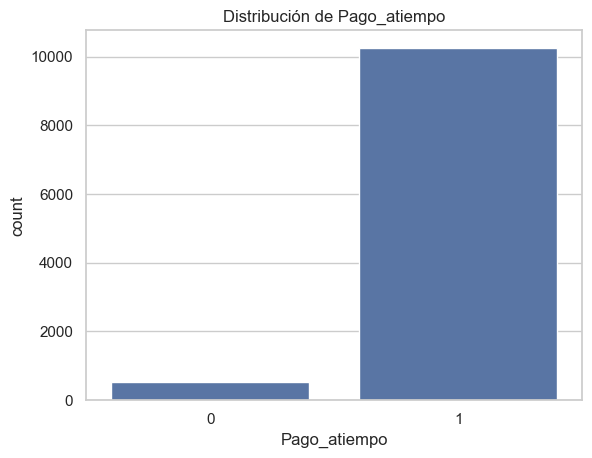

Pago_atiempo
1   0.95
0   0.05
Name: proportion, dtype: float64

In [31]:
# Distribución de la variable objetivo
sns.countplot(x="Pago_atiempo", data=df)
plt.title("Distribución de Pago_atiempo")
plt.show()

df["Pago_atiempo"].value_counts(normalize=True).round(3)


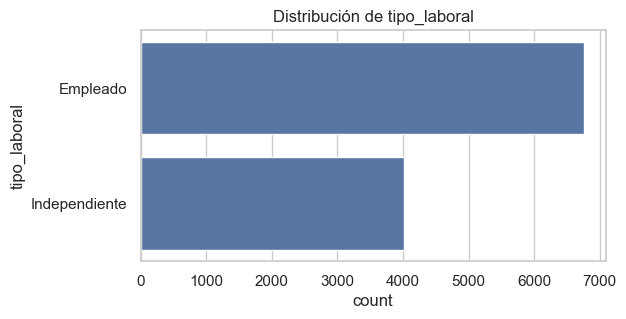

tipo_laboral
Empleado        0.63
Independiente   0.37
Name: proportion, dtype: float64



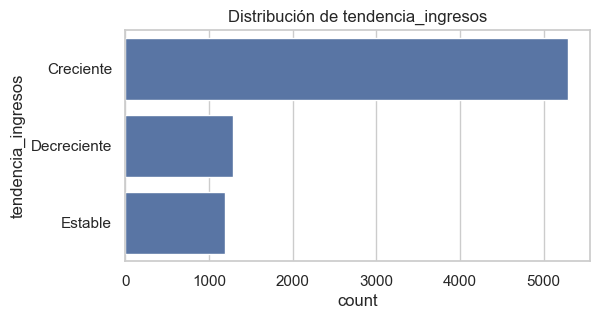

tendencia_ingresos
Creciente     0.68
Decreciente   0.17
Estable       0.15
Name: proportion, dtype: float64



In [32]:
# Countplots para variables categóricas: se recorre la lista 'categoricas' (tipo_laboral,
# tendencia_ingresos) generando el gráfico y las proporciones para cada una automáticamente,
# en vez de repetir el mismo bloque de código a mano por cada variable.
for c in categoricas:
    plt.figure(figsize=(6, 3))
    sns.countplot(y=c, data=df, order=df[c].value_counts().index)
    plt.title(f"Distribución de {c}")
    plt.show()
    print(df[c].value_counts(normalize=True).round(3))
    print()


In [33]:
df.groupby("tendencia_ingresos")["promedio_ingresos_datacredito"].describe()

,count,mean,std,min,25%,50%,75%,max
tendencia_ingresos,,,,,,,,
Creciente,"5,294.00","2,057,518.46","2,136,839.71",0.00,"939,017.00","1,219,160.00","2,338,843.75","28,889,623.00"
Decreciente,"1,291.00","2,284,108.31","2,484,949.92","30,285.00","933,473.00","1,420,217.00","2,760,415.50","38,106,581.00"
Estable,"1,188.00","1,404,659.00","1,285,271.72",0.00,"908,526.00","1,000,000.00","1,542,769.25","17,232,233.00"


**Relación tendencia_ingresos vs. nivel de ingreso:** se observan diferencias moderadas en `promedio_ingresos_datacredito` entre categorías de `tendencia_ingresos` (Decreciente: media $2.28M; Creciente: media $2.06M; Estable: media $1.40M). La relación no es dramática, y cabe notar que ambas variables miden aspectos distintos del ingreso (nivel vs. dirección de cambio), por lo que no se esperaría necesariamente una correlación fuerte entre ellas. No se detecta evidencia suficiente para considerar `tendencia_ingresos` como un dato corrupto, a diferencia de lo hallado en `puntaje`.

## 4. Análisis bivariable

Cruzamos cada variable contra la variable objetivo `Pago_atiempo`, para identificar cuáles muestran relación con el comportamiento de pago.

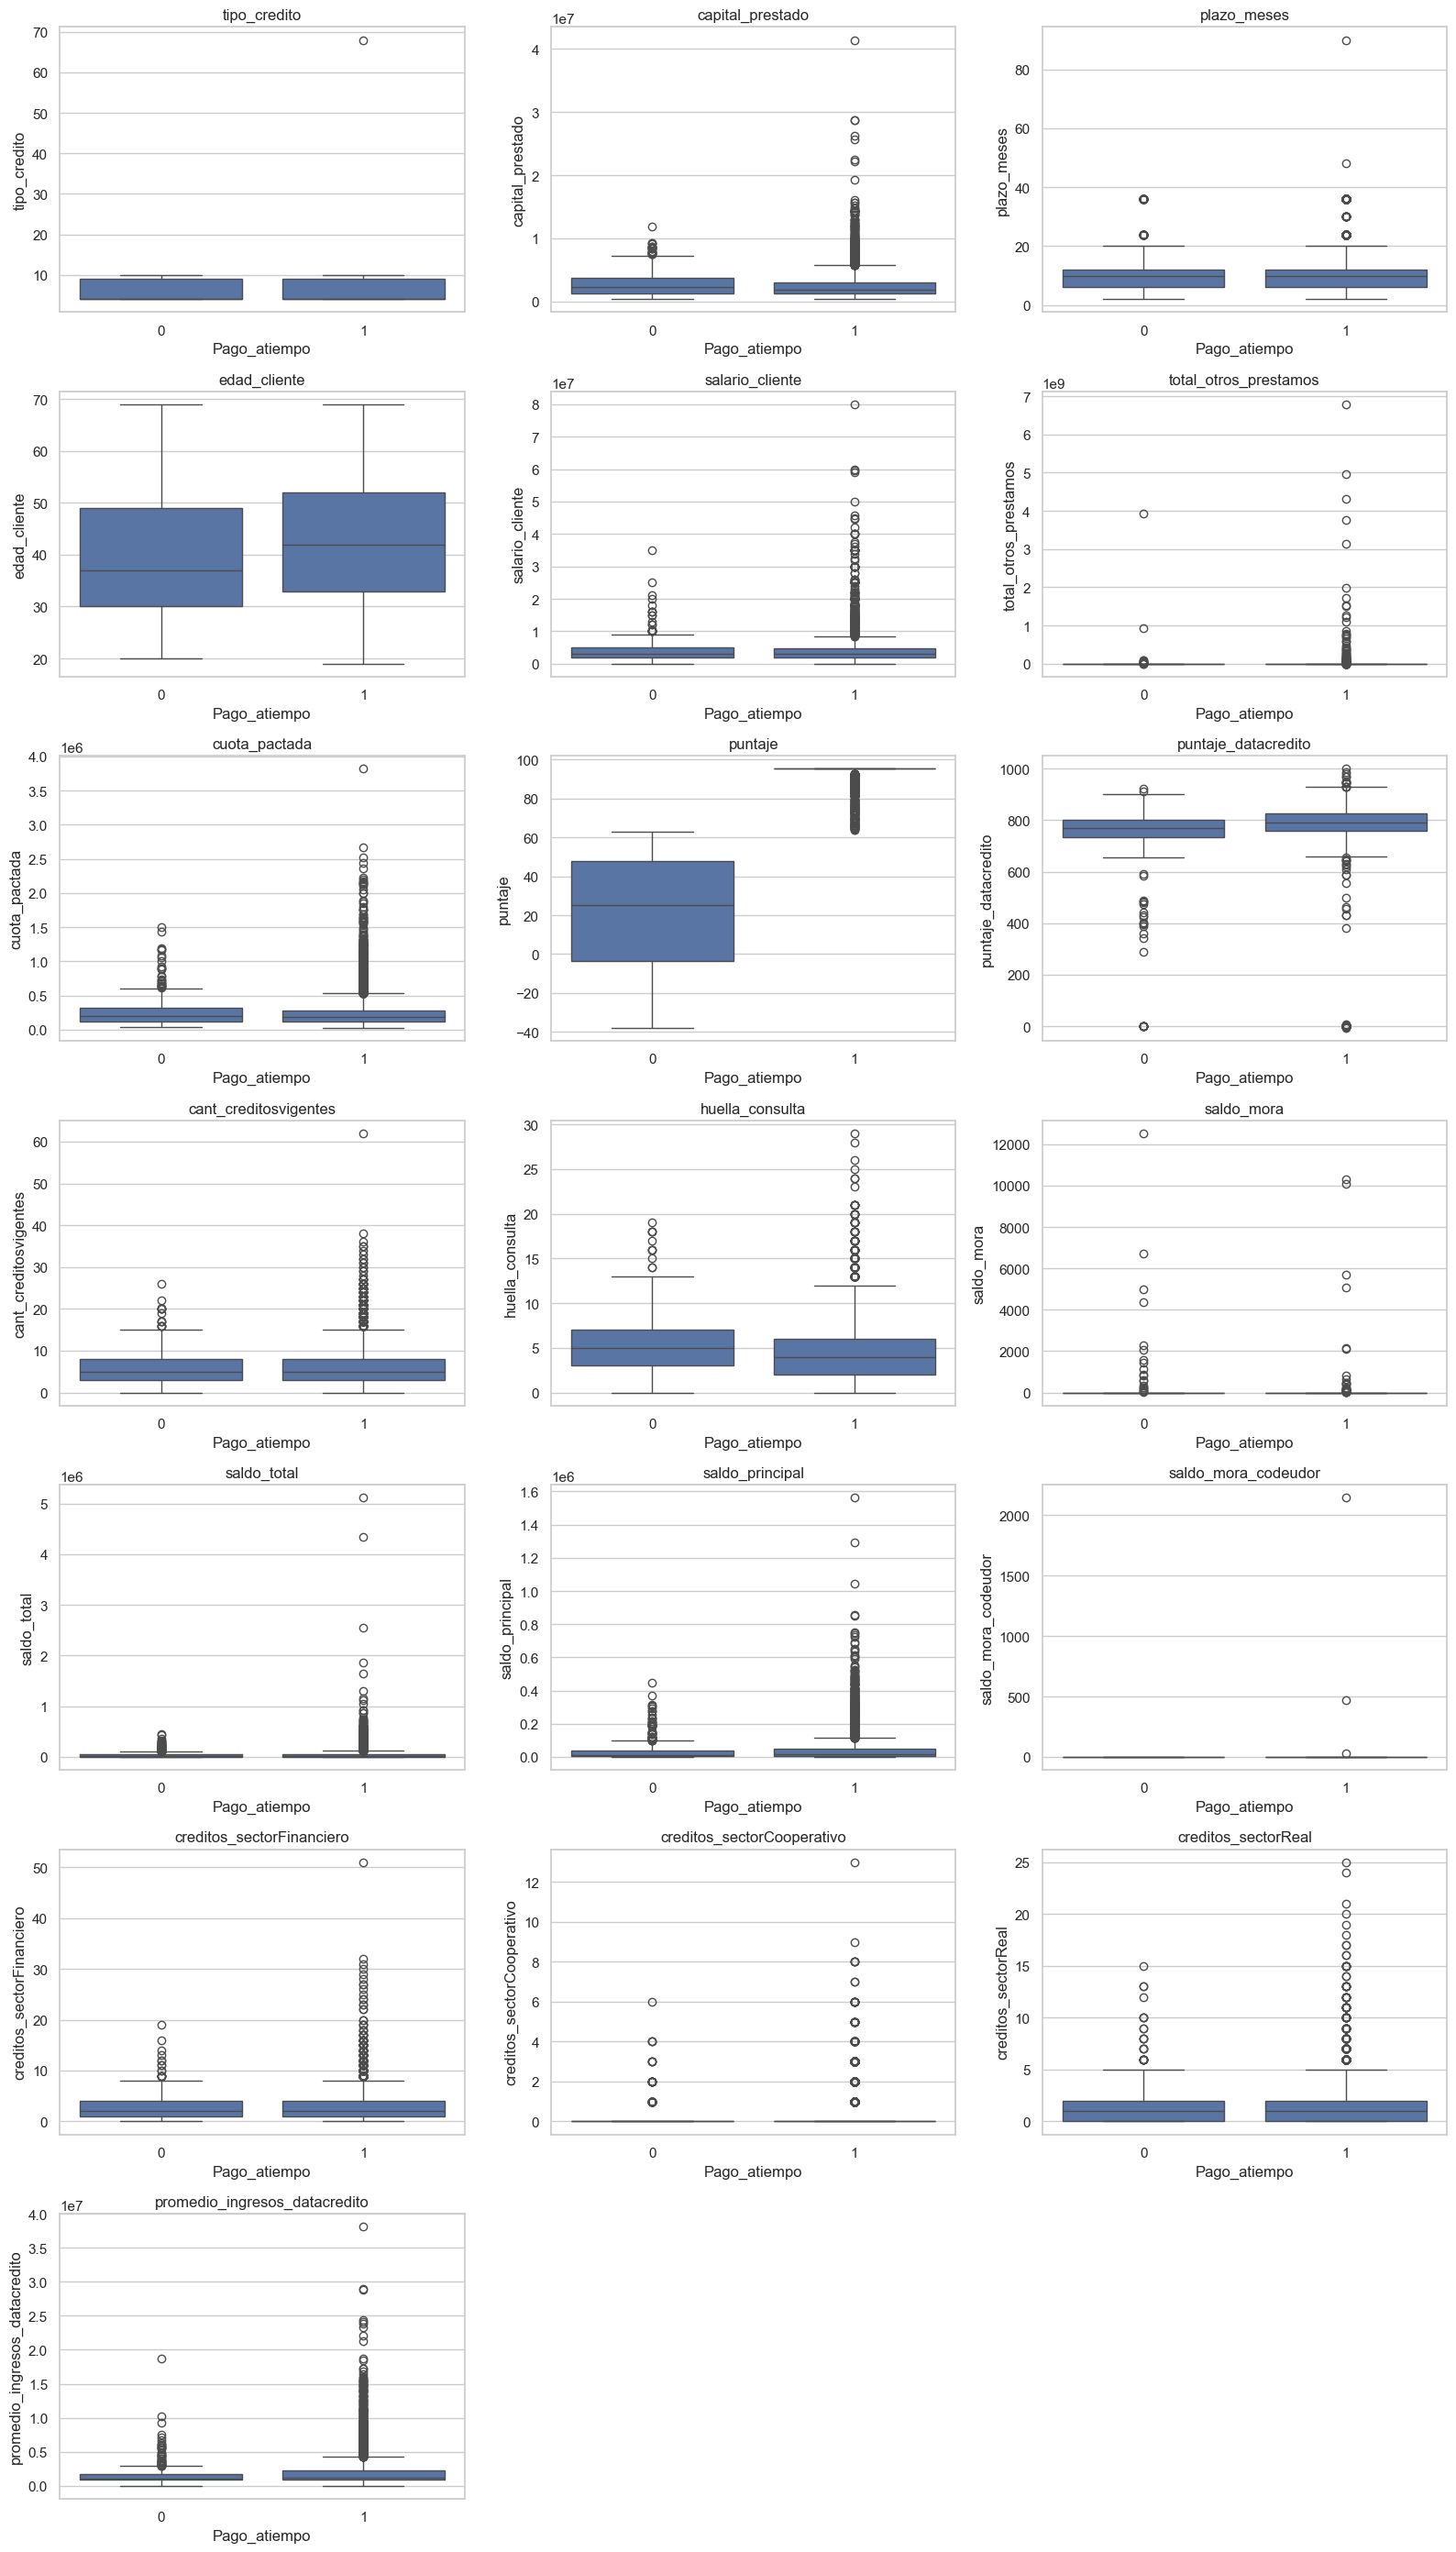

In [34]:
# Numéricas vs target: boxplot comparando distribución según la clase
fig, axes = plt.subplots(nrows=(len(numericas) + 2) // 3, ncols=3, figsize=(16, 4 * ((len(numericas) + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numericas):
    sns.boxplot(x="Pago_atiempo", y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Interpretación:** excluyendo `puntaje` (ver hallazgo de leakage), ninguna variable numérica separa con claridad a quienes pagan de quienes no. Las diferencias más visibles están en `edad_cliente` (mediana de 37 años en quienes no pagan vs. 42 en quienes pagan), `puntaje_datacredito` (768 vs. 792), `capital_prestado` (mediana de $2.27M vs. $1.91M) y `huella_consulta` (5 vs. 4 consultas). El perfil de riesgo apunta a clientes más jóvenes, con menor puntaje en centrales de riesgo, créditos más altos y más consultas recientes. Las diferencias son moderadas, por lo que el modelo deberá combinar varias variables en lugar de apoyarse en una sola.

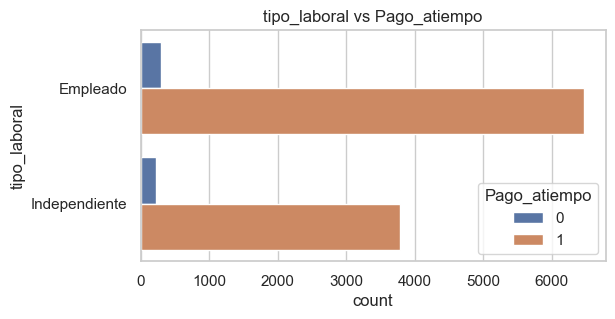

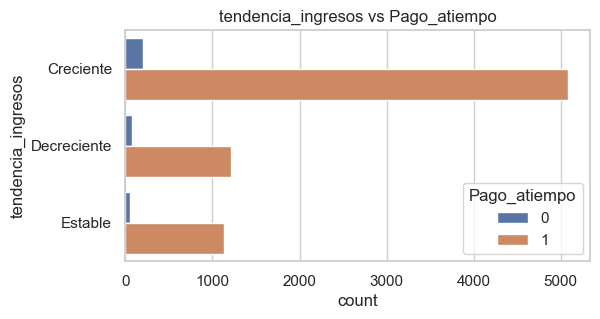

In [35]:
# Categóricas vs target
for c in categoricas:
    plt.figure(figsize=(6, 3))
    sns.countplot(y=c, hue="Pago_atiempo", data=df)
    plt.title(f"{c} vs Pago_atiempo")
    plt.show()


In [36]:
# Tabla cruzada con porcentajes, más fácil de leer que el gráfico para sacar números concretos
for c in categoricas:
    print(f"--- {c} vs Pago_atiempo ---")
    print(pd.crosstab(df[c], df["Pago_atiempo"], normalize="index").round(3))
    print()


--- tipo_laboral vs Pago_atiempo ---
Pago_atiempo     0    1
tipo_laboral           
Empleado      0.04 0.96
Independiente 0.06 0.94

--- tendencia_ingresos vs Pago_atiempo ---
Pago_atiempo          0    1
tendencia_ingresos          
Creciente          0.04 0.96
Decreciente        0.06 0.94
Estable            0.05 0.95



**Interpretación:** `tipo_laboral` muestra una diferencia leve (6% de no pago en independientes vs. 4% en empleados), coherente con la mayor variabilidad de ingresos de los trabajadores independientes. `tendencia_ingresos` no muestra diferencias relevantes entre categorías (94-96% de pago a tiempo en las tres), cercanas al promedio general del dataset (95%) — es candidata a tener bajo poder predictivo en el modelo, a pesar de no ser un dato corrupto.


## 5. Análisis multivariable

Revisamos relaciones entre variables numéricas entre sí (correlación) y de forma conjunta con la variable objetivo.

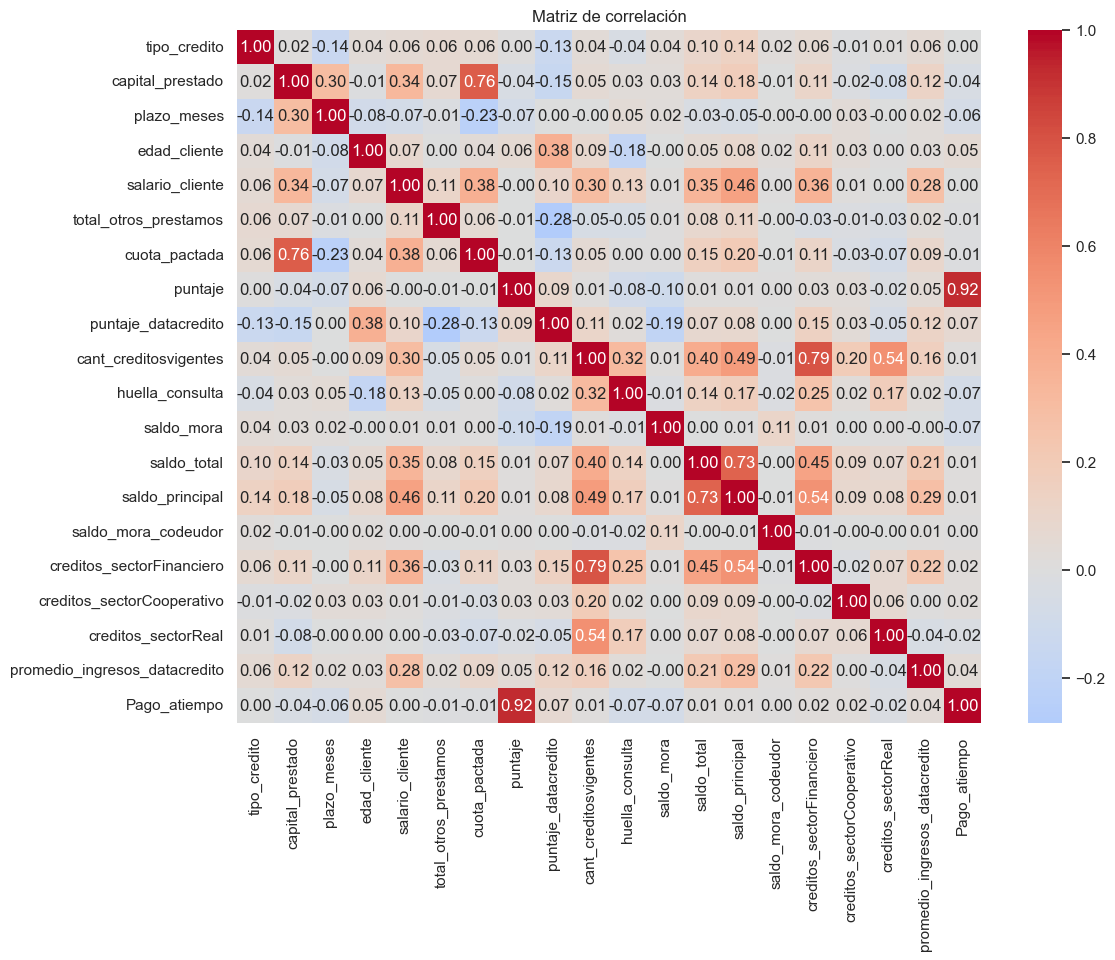

In [37]:
plt.figure(figsize=(12, 9))
corr = df[numericas + ["Pago_atiempo"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


**Interpretación:** `puntaje` presenta una correlación de 0.88 con el target, confirmando el leakage detectado. El resto de las variables tiene correlaciones lineales muy bajas con `Pago_atiempo` (menores a 0.08 en valor absoluto), lo que sugiere relaciones débiles o no lineales; modelos basados en árboles podrían capturarlas mejor que uno lineal. Se detectan tres pares de predictores con colinealidad alta: `capital_prestado` y `cuota_pactada` (0.76), `cant_creditosvigentes` y `creditos_sectorFinanciero` (0.79), y `saldo_total` y `saldo_principal` (0.73). Se evaluará conservar una variable de cada par en la ingeniería de características.

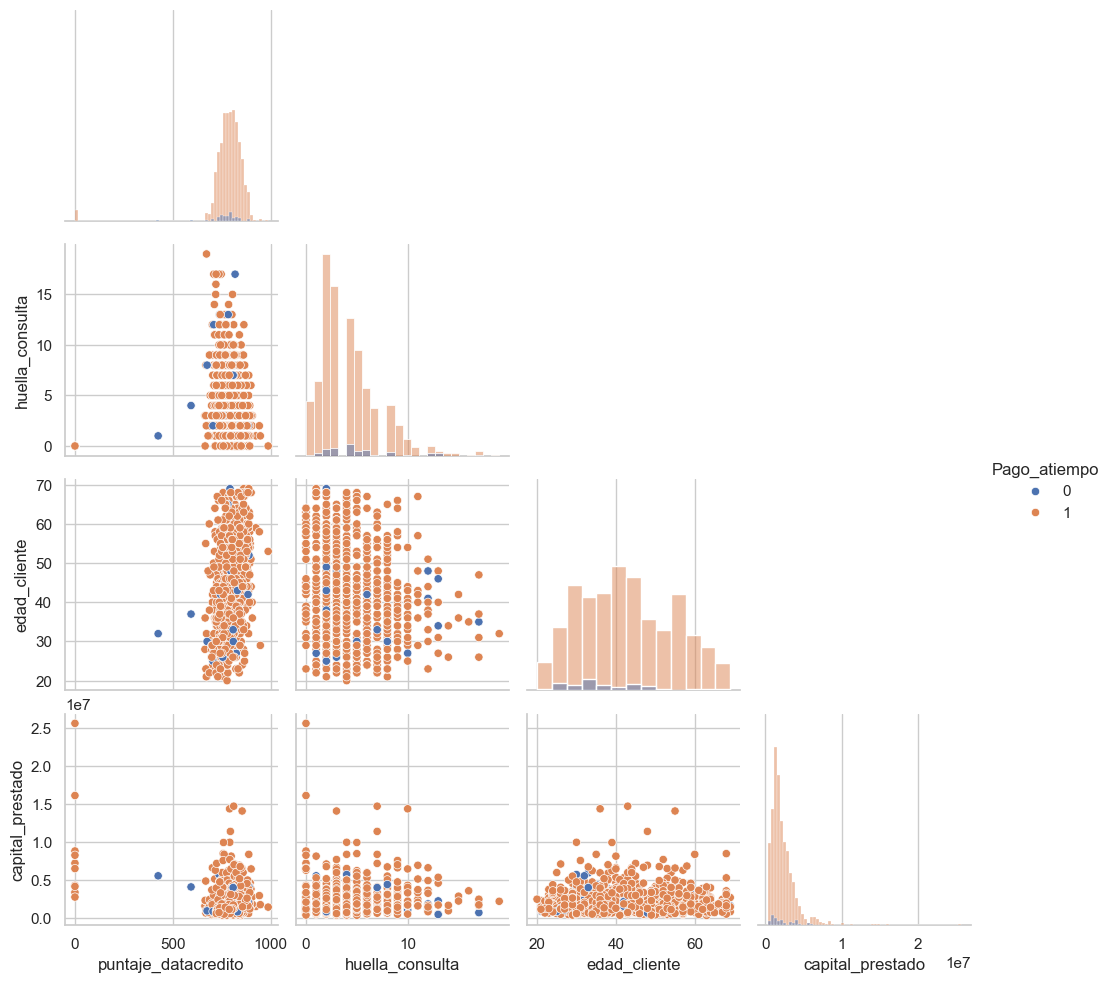

In [38]:
# Pairplot: puede ser pesado con muchas columnas, se usa una muestra del dataset
# y un subconjunto de variables numéricas (ajustar la lista según lo que resultó
# más relevante en el paso anterior)
subset_cols = ["puntaje_datacredito", "huella_consulta", "edad_cliente", "capital_prestado", "Pago_atiempo"]
muestra = df[subset_cols].sample(n=min(1000, len(df)), random_state=42)

sns.pairplot(muestra, hue="Pago_atiempo", diag_kind="hist", corner=True)
plt.show()


## 6. Conclusiones

- **Calidad de datos:** se detectaron y corrigieron cuatro problemas de carga: 58 valores numéricos inválidos en `tendencia_ingresos`, 150 filas con edad de 121-123 años y salario inconsistente, y 5 salarios adicionales superiores a $100M. Los nulos restantes tienen una estrategia de imputación definida por columna (sección 2).
- **Data leakage:** `puntaje` se calcula a partir del resultado de pago y se excluirá del modelo.
- **Desbalance de clases:** 95% / 5%. El modelado deberá usar técnicas de balanceo y priorizar Recall, F1 y AUC sobre Accuracy.
- **Variables con mayor señal:** `edad_cliente`, `puntaje_datacredito`, `capital_prestado`, `huella_consulta` y `tipo_laboral`, con diferencias moderadas entre clases.
- **Colinealidad:** tres pares de variables con correlación superior a 0.7, a revisar en la selección de características.
- **Transformaciones sugeridas:** transformación logarítmica para variables monetarias con fuerte sesgo a la derecha (`capital_prestado`, `salario_cliente`, `saldo_total`), y conversión de `tipo_credito` a categórica, ya que sus valores son códigos y no cantidades.
- **Atributos derivados posibles:** relación `cuota_pactada / salario_cliente` como indicador de capacidad de pago.